# 05 · FT-Transformer

A Feature Tokenizer Transformer (Gorishniy et al., 2021) via `tab_transformer_pytorch`. Categorical features
are embedded, continuous features are tokenized, and the token sequence passes through a transformer
encoder. Hyperparameters were tuned with Optuna TPE (50 trials with pruning). **Best checkpoint: 82.0% test accuracy.**

> **Note:** this is an archival notebook from the original MTFC 2025 run. Outputs are preserved as-is; the dataset (`ObesityDataSet_raw_and_data_sinthetic.csv`) and trained model files are not included in the repo (see the main README for download links).

## Data preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tab_transformer_pytorch import TabTransformer

# ------------------------
# Data Loading and Preprocessing
# ------------------------

# Load data and drop unwanted columns
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df = df.drop(['Gender', 'Weight'], axis=1)

# Define target column
target_col = "NObeyesdad"

# Identify categorical and numerical columns:
# Assume categorical columns are of object type
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns.tolist() if col != target_col]
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()
# Remove the target column from numerical columns (if present)
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Convert target to numeric labels
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col])

# Process categorical columns: use label encoding so that each category is represented as an integer index.
for col in categorical_cols:
    le_cat = LabelEncoder()
    df[col] = le_cat.fit_transform(df[col])

# Scale numerical columns using z-score scaling
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Create separate DataFrames for categorical and continuous features

X_cat = df[categorical_cols]
X_cont = df[numerical_cols]
y = df[target_col]

# For the TabTransformer, we need the number of unique values per categorical feature.
categories = [int(X_cat[col].nunique()) for col in categorical_cols]
num_continuous = len(numerical_cols)
print("Categories (cardinalities):", categories)
print("Number of continuous features:", num_continuous)

Categorical columns: ['family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Numerical columns: ['Age', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categories (cardinalities): [2, 2, 4, 2, 2, 4, 5]
Number of continuous features: 7


In [2]:
# ------------------------
# Train / Validation / Test Split
# ------------------------

# First, split into training+validation and test sets (80% train+val, 20% test)
X_cat_train_val, X_cat_test, X_cont_train_val, X_cont_test, y_train_val, y_test = train_test_split(
    X_cat, X_cont, y, test_size=0.2, stratify=y, random_state=42
)

# Then split training+validation into training and validation sets (80% train, 20% validation)
X_cat_train, X_cat_val, X_cont_train, X_cont_val, y_train, y_val = train_test_split(
    X_cat_train_val, X_cont_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=42
)

# ------------------------
# Convert DataFrames to torch tensors
# ------------------------

# For categorical data, convert to torch.long tensors
X_cat_train_tensor = torch.tensor(X_cat_train.values, dtype=torch.long)
X_cat_val_tensor   = torch.tensor(X_cat_val.values, dtype=torch.long)
X_cat_test_tensor  = torch.tensor(X_cat_test.values, dtype=torch.long)

# For continuous data, convert to torch.float32 tensors
X_cont_train_tensor = torch.tensor(X_cont_train.values, dtype=torch.float32)
X_cont_val_tensor   = torch.tensor(X_cont_val.values, dtype=torch.float32)
X_cont_test_tensor  = torch.tensor(X_cont_test.values, dtype=torch.float32)

# Target tensor
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long)

# ------------------------
# Create a Custom Dataset
# ------------------------

class TabularDataset(Dataset):
    def __init__(self, X_cat, X_cont, y):
        self.X_cat = X_cat
        self.X_cont = X_cont
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_cont[idx], self.y[idx]

train_dataset = TabularDataset(X_cat_train_tensor, X_cont_train_tensor, y_train_tensor)
val_dataset   = TabularDataset(X_cat_val_tensor, X_cont_val_tensor, y_val_tensor)
test_dataset  = TabularDataset(X_cat_test_tensor, X_cont_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

## Hyperparameter tuning with Optuna (TPE)

The full study was run separately; its best parameters are summarized in the next two cells and hard-coded
into the model below.

In [3]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tab_transformer_pytorch import FTTransformer

# Define your device and assume train_loader and val_loader are predefined DataLoader objects.
device = torch.device("mps" if torch.cuda.is_available() else "cpu")

# Assume categories and num_continuous are defined based on your dataset.
# For example:
# categories = [cardinality1, cardinality2, ...]
# num_continuous = number_of_continuous_features

def objective(trial):
    # Define candidate dimensions and possible heads.
    possible_dims = [32, 64, 128, 256]
    # Only allow heads that divide all candidate dimensions.
    possible_heads = [h for h in [2, 4, 8, 16, 32] if all(d % h == 0 for d in possible_dims)]
    
    # Sample the number of attention heads from the valid set.
    heads = trial.suggest_categorical("heads", possible_heads)
    # Sample the embedding dimension from the candidate set.
    dim = trial.suggest_categorical("dim", possible_dims)
    # Since every candidate in possible_dims is divisible by any h in possible_heads, no further filtering is required.
    
    depth = trial.suggest_int("depth", 2, 5)
    attn_dropout = trial.suggest_float("attn_dropout", 0.1, 0.5)
    ff_dropout = trial.suggest_float("ff_dropout", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-5, log=True)
    num_epochs = trial.suggest_int("num_epochs", 10, 50)

    # Instantiate your FTTransformer model with the suggested hyperparameters.
    model = FTTransformer(
        categories=tuple(categories),
        num_continuous=num_continuous,
        dim=dim,
        depth=depth,
        heads=heads,
        attn_dropout=attn_dropout,
        ff_dropout=ff_dropout,
        dim_out=7  # Assuming 7 classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_val_acc = 0.0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_cat_batch, X_cont_batch, y_batch in train_loader:
            X_cat_batch = X_cat_batch.to(device)
            X_cont_batch = X_cont_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_cat_batch, X_cont_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * y_batch.size(0)
        avg_train_loss = train_loss / len(train_loader.dataset)

        # Evaluate on validation set.
        model.eval()
        val_loss = 0.0
        val_true = []
        val_pred = []
        with torch.no_grad():
            for X_cat_batch, X_cont_batch, y_batch in val_loader:
                X_cat_batch = X_cat_batch.to(device)
                X_cont_batch = X_cont_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_cat_batch, X_cont_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * y_batch.size(0)
                preds = outputs.argmax(dim=1)
                val_true.extend(y_batch.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_acc = np.mean(np.array(val_true) == np.array(val_pred))

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        best_val_loss = min(best_val_loss, avg_val_loss)

    trial.set_user_attr("val_accuracy", best_val_acc)
    return best_val_loss

# Create and optimize the study.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Best trial:")
trial = study.best_trial
print("  Best Validation Loss: {:.4f}".format(trial.value))
print("  Best Hyperparameters: ", trial.params)
print("  Best Validation Accuracy: {:.4f}".format(trial.user_attrs["val_accuracy"]))

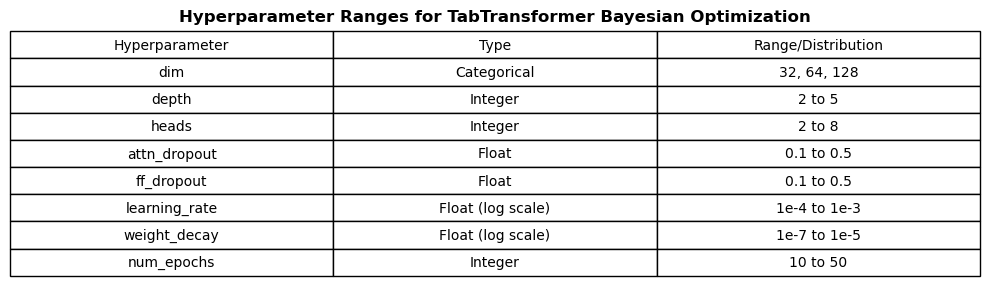

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the hyperparameter ranges data for the TabTransformer model.
hp_data = {
    "Hyperparameter": [
        "dim", 
        "depth", 
        "heads", 
        "attn_dropout", 
        "ff_dropout", 
        "learning_rate", 
        "weight_decay", 
        "num_epochs"
    ],
    "Type": [
        "Categorical", 
        "Integer", 
        "Integer", 
        "Float", 
        "Float", 
        "Float (log scale)", 
        "Float (log scale)",
        "Integer"
    ],
    "Range/Distribution": [
        "32, 64, 128", 
        "2 to 5", 
        "2 to 8", 
        "0.1 to 0.5", 
        "0.1 to 0.5", 
        "1e-4 to 1e-3", 
        "1e-7 to 1e-5",
        "10 to 50"
    ]
}

# Create a DataFrame.
df_hp = pd.DataFrame(hp_data)

# Create a figure and axis for the table.
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

# Create the table.
table = ax.table(cellText=df_hp.values,
                 colLabels=df_hp.columns,
                 cellLoc='center',
                 loc='center')

# Adjust table properties.
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Set the title of the graph.
plt.title("Hyperparameter Ranges for TabTransformer Bayesian Optimization", fontweight="bold", pad=5)

# Save and display the figure.
plt.tight_layout()
plt.savefig("tabtransformer_hyperparameter_ranges.png", dpi=300)
plt.show()

Optimal Hyperparameters:
Hyperparameter Optimal Value                                                                                              Interpretation
           dim           128 32: Embedding dimension for categorical features. A lower dimension can reduce overfitting and computation.
         depth             3          3: Number of transformer layers. A shallow architecture reduces complexity and speeds up training.
         heads             8           8: Number of attention heads. Sufficient for multi-view attention while keeping computations low.
  attn_dropout       0.24202                                       0.24202: Moderate dropout in attention layers to prevent overfitting.
    ff_dropout       0.39235                      0.39235: Slightly higher dropout in feed-forward layers for additional regularization.
 learning_rate       0.00048                               0.00048: A low learning rate ensures gradual convergence and model stability.
  weight_decay  

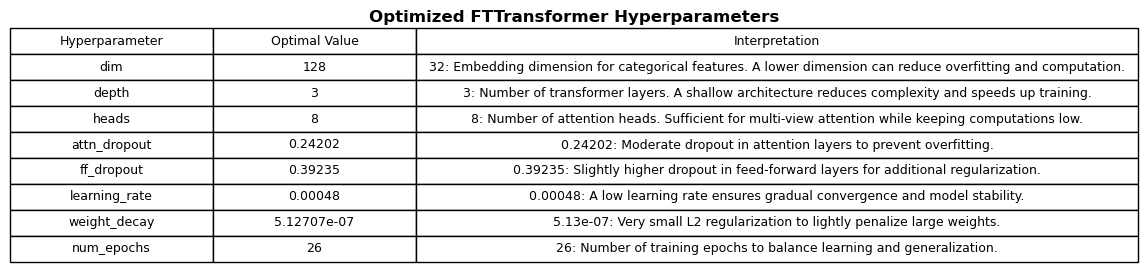

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Best hyperparameters from the Optuna study for TabTransformer.
best_params = {
    'dim': 128, 
    'depth': 3, 
    'heads': 8, 
    'attn_dropout': 0.24201550670440292, 
    'ff_dropout': 0.3923496747779344, 
    'learning_rate': 0.0004815730708625121, 
    'weight_decay': '5.12707e-07', 
    'num_epochs': 26
}

# Define interpretations for each hyperparameter.
interpretations = {
    "dim": "32: Embedding dimension for categorical features. A lower dimension can reduce overfitting and computation.",
    "depth": "3: Number of transformer layers. A shallow architecture reduces complexity and speeds up training.",
    "heads": "8: Number of attention heads. Sufficient for multi-view attention while keeping computations low.",
    "attn_dropout": "0.24202: Moderate dropout in attention layers to prevent overfitting.",
    "ff_dropout": "0.39235: Slightly higher dropout in feed-forward layers for additional regularization.",
    "learning_rate": "0.00048: A low learning rate ensures gradual convergence and model stability.",
    "weight_decay": "5.13e-07: Very small L2 regularization to lightly penalize large weights.",
    "num_epochs": "26: Number of training epochs to balance learning and generalization."
}

# Build a list of tuples for hyperparameters with interpretations.
hp_list = []
for hp, value in best_params.items():
    if hp in interpretations:
        # Round numeric values to 5 decimal places if applicable.
        rounded_value = round(value, 5) if isinstance(value, (int, float)) else value
        hp_list.append((hp, rounded_value, interpretations[hp]))

df_best = pd.DataFrame(hp_list, columns=["Hyperparameter", "Optimal Value", "Interpretation"])

# Print the DataFrame in console for verification.
print("Optimal Hyperparameters:")
print(df_best.to_string(index=False))

# Create a figure and axis for the table with reduced margins.
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

# Create the table from the DataFrame.
table = ax.table(cellText=df_best.values,
                 colLabels=df_best.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Manually adjust column widths:
for i in range(len(df_best) + 1):  # iterate over rows, including header row
    table[(i, 0)].set_width(0.18)  # Hyperparameter column (narrow)
    table[(i, 1)].set_width(0.18)  # Optimal Value column (narrow)
    table[(i, 2)].set_width(0.64)  # Interpretation column (wide)

# Set the title for the table.
plt.title("Optimized FTTransformer Hyperparameters", fontweight="bold", pad=0.5)

# Adjust subplot parameters to reduce extra margins.
plt.subplots_adjust(left=0.03, right=0.97, top=0.85, bottom=0.05)

# Save the figure as a PNG file with minimal whitespace.
plt.savefig("FTTransformer/optimal_hyperparameters_fttransformer.png", dpi=300, bbox_inches='tight')
plt.show()

## Model

In [6]:
from tab_transformer_pytorch import FTTransformer
# ------------------------
# Initialize the TabTransformer Model
# ------------------------
model = FTTransformer(
    categories = tuple(categories),    # Tuple of cardinalities for categorical features
    num_continuous = num_continuous,     # Number of continuous features
    dim = 128,                          # Embedding dimension for categorical features
    depth = 3,                         # Number of Transformer layers
    heads = 8,                         # Number of attention heads
    attn_dropout = 0.24201550670440292,                # Dropout for attention
    ff_dropout = 0.3923496747779344,                  # Dropout for feed-forward layers
    #mlp_hidden_mults = (4, 2),            # Hidden layer multipliers for the MLP head
    dim_out = 7
)

print(model)

device = torch.device("cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0004815730708625121, weight_decay = 5.127077152810453e-07)

FTTransformer(
  (categorical_embeds): Embedding(23, 128)
  (numerical_embedder): NumericalEmbedder()
  (transformer): Transformer(
    (expand_streams): Reduce('b ... -> (b s) ...', 'repeat', s=4)
    (reduce_streams): Reduce('(b s) ... -> b ...', 'sum', s=4)
    (layers): ModuleList(
      (0-2): 3 x ModuleList(
        (0): HyperConnections(
          (branch): Attention(
            (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (to_qkv): Linear(in_features=128, out_features=384, bias=False)
            (to_out): Linear(in_features=128, out_features=128, bias=False)
            (dropout): Dropout(p=0.24201550670440292, inplace=False)
          )
          (act): Tanh()
          (norm): RMSNorm()
          (dropout): Dropout(p=0.0, inplace=False)
          (residual_transform): Identity()
        )
        (1): HyperConnections(
          (branch): Sequential(
            (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (1): Linear(i

## Training (26 epochs, best validation checkpoint saved)

In [7]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

num_epochs = 26
best_val_loss = float('inf')

# Lists to store history
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
train_auc_history = []
val_auc_history = []

for epoch in range(num_epochs):
    start_epoch = time.time()
    
    # ---- Training Phase ----
    model.train()
    total_loss = 0.0
    train_true = []
    train_pred = []
    train_prob_list = []  # to accumulate probability vectors for each sample
    
    for X_cat_batch, X_cont_batch, y_batch in train_loader:
        X_cat_batch = X_cat_batch.to(device)
        X_cont_batch = X_cont_batch.to(device)
        y_batch = y_batch.to(device)
        #print(X_cat_batch.shape, X_cont_batch.shape)
        optimizer.zero_grad()
        outputs = model(X_cat_batch, X_cont_batch)  # shape: (batch_size, num_classes)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y_batch.size(0)
        
        preds = outputs.argmax(dim=1)
        train_true.extend(y_batch.cpu().numpy())
        train_pred.extend(preds.cpu().numpy())
        probs = torch.softmax(outputs, dim=1)
        train_prob_list.append(probs.cpu().detach().numpy())
    
    avg_train_loss = total_loss / len(train_loader.dataset)
    train_loss_history.append(avg_train_loss)
    train_acc = accuracy_score(train_true, train_pred)
    train_acc_history.append(train_acc)
    train_prob = np.concatenate(train_prob_list, axis=0)
    try:
        train_auc = roc_auc_score(train_true, train_prob, multi_class='ovr', average='macro')
    except ValueError:
        train_auc = np.nan
    train_auc_history.append(train_auc)
    
    # ---- Validation Phase ----
    model.eval()
    total_val_loss = 0.0
    val_true = []
    val_pred = []
    val_prob_list = []
    with torch.no_grad():
        for X_cat_batch, X_cont_batch, y_batch in val_loader:
            X_cat_batch = X_cat_batch.to(device)
            X_cont_batch = X_cont_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_cat_batch, X_cont_batch)
            loss = criterion(outputs, y_batch)
            total_val_loss += loss.item() * y_batch.size(0)
            
            preds = outputs.argmax(dim=1)
            val_true.extend(y_batch.cpu().numpy())
            val_pred.extend(preds.cpu().numpy())
            probs = torch.softmax(outputs, dim=1)
            val_prob_list.append(probs.cpu().detach().numpy())
            
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_loss_history.append(avg_val_loss)
    val_acc = accuracy_score(val_true, val_pred)
    val_acc_history.append(val_acc)
    val_prob = np.concatenate(val_prob_list, axis=0)
    try:
        val_auc = roc_auc_score(val_true, val_prob, multi_class='ovr', average='macro')
    except ValueError:
        val_auc = np.nan
    val_auc_history.append(val_auc)

    end_epoch = time.time()
    epoch_duration = end_epoch - start_epoch

    print(f"Epoch {epoch+1}/{num_epochs} - Duration: {epoch_duration:.2f}s")
    print(f"  Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f}, AUC: {train_auc:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}, AUC: {val_auc:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "fttransformer_valbest.pt")
        print("Best model updated and saved.")

print("Training complete.")

Epoch 1/26 - Duration: 2.71s
  Train Loss: 1.7442, Acc: 0.3089, AUC: 0.6934
  Val   Loss: 1.3651, Acc: 0.4941, AUC: 0.8438
Best model updated and saved.
Epoch 2/26 - Duration: 2.50s
  Train Loss: 1.2779, Acc: 0.5133, AUC: 0.8405
  Val   Loss: 1.0677, Acc: 0.6154, AUC: 0.8957
Best model updated and saved.
Epoch 3/26 - Duration: 2.54s
  Train Loss: 1.0810, Acc: 0.5956, AUC: 0.8861
  Val   Loss: 1.0063, Acc: 0.6450, AUC: 0.8980
Best model updated and saved.
... (74 lines omitted) ...
  Val   Loss: 0.6483, Acc: 0.8225, AUC: 0.9651
Epoch 25/26 - Duration: 2.66s
  Train Loss: 0.2295, Acc: 0.9222, AUC: 0.9941
  Val   Loss: 0.6582, Acc: 0.8166, AUC: 0.9650
Epoch 26/26 - Duration: 2.73s
  Train Loss: 0.2212, Acc: 0.9267, AUC: 0.9944
  Val   Loss: 0.6784, Acc: 0.8047, AUC: 0.9641
Training complete.


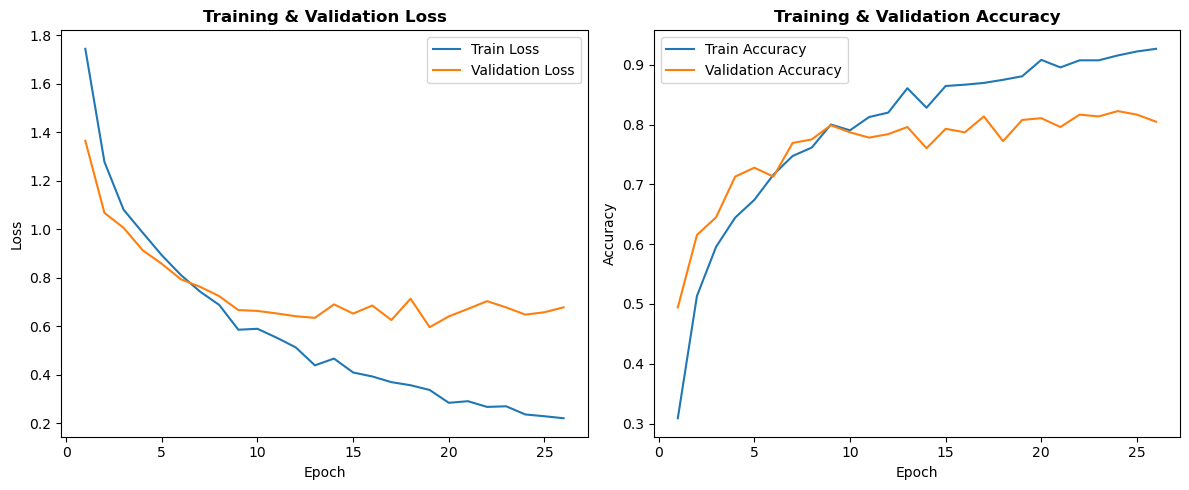

In [8]:
# --- Plot Training History ---

epochs = range(1, num_epochs+1)
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss', fontweight = "bold")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, label='Train Accuracy')
plt.plot(epochs, val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy', fontweight = "bold")
plt.legend()

plt.tight_layout()
plt.savefig("fttransformer/fttransformer_training_history.png", dpi=300)
plt.show()

## Test-set evaluation

Final-epoch weights:

In [9]:
# ------------------------
# Evaluate on Test Set
# ------------------------
model.eval()
test_true = []
test_pred = []
test_prob_list = []
with torch.no_grad():
    for X_cat_batch, X_cont_batch, y_batch in test_loader:
        X_cat_batch = X_cat_batch.to(device)
        X_cont_batch = X_cont_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_cat_batch, X_cont_batch)
        preds = outputs.argmax(dim=1)
        test_true.extend(y_batch.cpu().numpy())
        test_pred.extend(preds.cpu().numpy())
        probs = torch.softmax(outputs, dim=1)
        test_prob_list.append(probs.cpu().detach().numpy())
        
test_acc = accuracy_score(test_true, test_pred)
test_precision = precision_score(test_true, test_pred, average='macro', zero_division=0)
test_recall = recall_score(test_true, test_pred, average='macro', zero_division=0)
test_prob = np.concatenate(test_prob_list, axis=0)
try:
    test_auc = roc_auc_score(test_true, test_prob, multi_class='ovr', average='macro')
except ValueError:
    test_auc = np.nan
print("Test Metrics:")
print(f"  Acc: {test_acc:.4f}, AUC: {test_auc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

Test Metrics:
  Acc: 0.7967, AUC: 0.9591, Precision: 0.7911, Recall: 0.7952


Best validation checkpoint (the model reported in the paper):

In [10]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

# Load the saved model state (adjust map_location as needed)
model_val = FTTransformer(
    categories = tuple(categories),    # Tuple of cardinalities for categorical features
    num_continuous = num_continuous,     # Number of continuous features
    dim = 128,                          # Embedding dimension for categorical features
    depth = 3,                         # Number of Transformer layers
    heads = 8,                         # Number of attention heads
    attn_dropout = 0.24201550670440292,                # Dropout for attention
    ff_dropout = 0.3923496747779344,                  # Dropout for feed-forward layers
    #mlp_hidden_mults = (4, 2),            # Hidden layer multipliers for the MLP head
    dim_out = 7
)
model_val.load_state_dict(torch.load("fttransformer/fttransformer_valbest.pt", map_location=device))
model_val.to(device)
model_val.eval()

test_true = []
test_pred = []
test_prob_list = []

with torch.no_grad():
    for X_cat_batch, X_cont_batch, y_batch in test_loader:
        X_cat_batch = X_cat_batch.to(device)
        X_cont_batch = X_cont_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model_val(X_cat_batch, X_cont_batch)
        preds = outputs.argmax(dim=1)
        test_true.extend(y_batch.cpu().numpy())
        test_pred.extend(preds.cpu().numpy())
        probs = torch.softmax(outputs, dim=1)
        test_prob_list.append(probs.cpu().detach().numpy())
        
test_acc = accuracy_score(test_true, test_pred)
test_precision = precision_score(test_true, test_pred, average='macro', zero_division=0)
test_recall = recall_score(test_true, test_pred, average='macro', zero_division=0)
test_prob = np.concatenate(test_prob_list, axis=0)
try:
    test_auc = roc_auc_score(test_true, test_prob, multi_class='ovr', average='macro')
except ValueError:
    test_auc = np.nan

print("Test Metrics:")
print(f"  Acc: {test_acc:.4f}, AUC: {test_auc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

Test Metrics:
  Acc: 0.8203, AUC: 0.9634, Precision: 0.8167, Recall: 0.8181


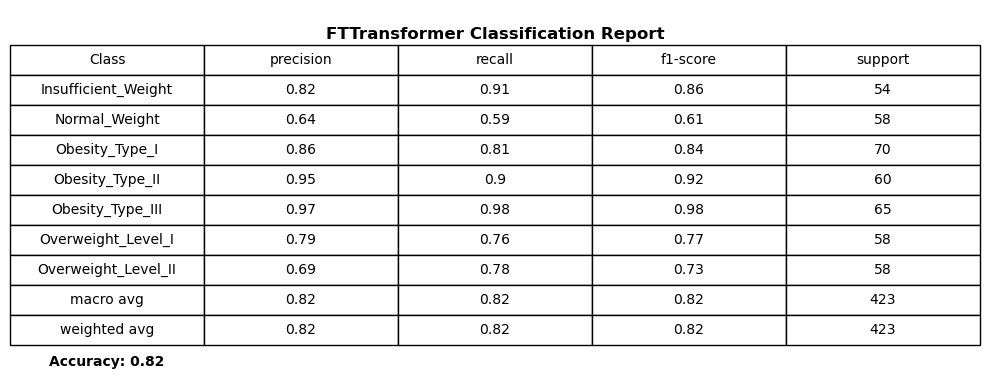

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Define a mapping from class labels (as strings) to descriptive names.
label_mapping = {
    "0": "Insufficient_Weight",
    "1": "Normal_Weight",
    "2": "Obesity_Type_I",
    "3": "Obesity_Type_II",
    "4": "Obesity_Type_III",
    "5": "Overweight_Level_I",
    "6": "Overweight_Level_II"
}

# Generate the classification report as a dictionary.
report_dict = classification_report(test_true, test_pred, output_dict=True)

# Extract accuracy separately.
accuracy_val = report_dict.pop("accuracy")

# Replace keys for individual classes with their descriptive names.
for key in list(report_dict.keys()):
    if key in label_mapping:
        report_dict[label_mapping[key]] = report_dict.pop(key)

# Define the desired order for the rows.
desired_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "macro avg",
    "weighted avg"
]

# Convert the remaining dictionary to a DataFrame.
df_report = pd.DataFrame(report_dict).transpose().reset_index().rename(columns={"index": "Class"})

# Reorder rows according to desired_order.
df_report["order"] = df_report["Class"].apply(lambda x: desired_order.index(x) if x in desired_order else 999)
df_report = df_report.sort_values("order").drop("order", axis=1).reset_index(drop=True)

# Format the DataFrame.
df_report = df_report[["Class", "precision", "recall", "f1-score", "support"]]
df_report["precision"] = df_report["precision"].round(2)
df_report["recall"] = df_report["recall"].round(2)
df_report["f1-score"] = df_report["f1-score"].round(2)
df_report["support"] = df_report["support"].astype(int)

# Create a figure to display the table.
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 cellLoc='center', 
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Add the Accuracy value at the bottom right of the figure.
plt.text(0.04, 0.03, f"Accuracy: {accuracy_val:.2f}", transform=ax.transAxes,
         fontsize=10, fontweight="bold", va='bottom', ha='left')

plt.title("FTTransformer Classification Report", fontweight="bold", y=0.9)
plt.tight_layout()
plt.savefig("FTTransformer/fttransformer_classification_report.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("\nClassification Report:\n", classification_report(test_true, test_pred, target_names=le_target.classes_))


Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.82      0.91      0.86        54
      Normal_Weight       0.64      0.59      0.61        58
     Obesity_Type_I       0.86      0.81      0.84        70
    Obesity_Type_II       0.95      0.90      0.92        60
   Obesity_Type_III       0.97      0.98      0.98        65
 Overweight_Level_I       0.79      0.76      0.77        58
Overweight_Level_II       0.69      0.78      0.73        58

           accuracy                           0.82       423
          macro avg       0.82      0.82      0.82       423
       weighted avg       0.82      0.82      0.82       423



Confusion Matrix:
[[49  4  0  0  0  1  0]
 [ 8 34  3  0  0  5  8]
 [ 1  3 57  0  0  3  6]
 [ 0  2  1 54  1  1  1]
 [ 0  1  0  0 64  0  0]
 [ 0  7  2  0  0 44  5]
 [ 2  2  3  3  1  2 45]]


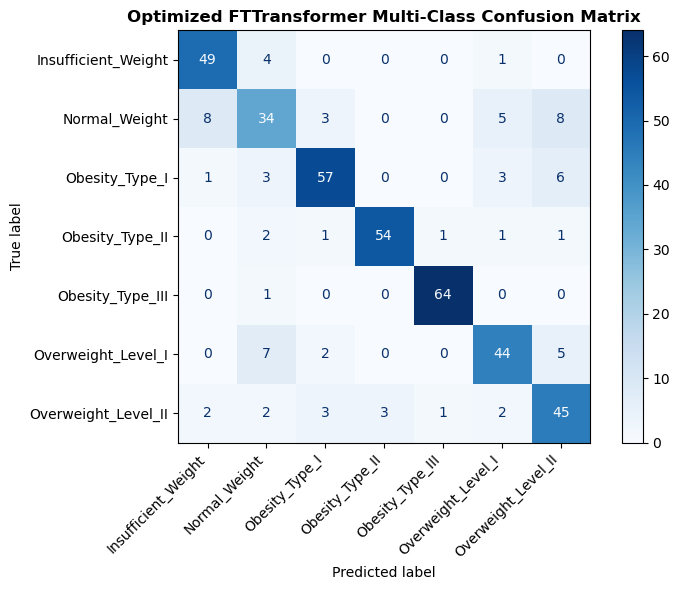

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Generate the confusion matrix
cm = confusion_matrix(test_true, test_pred)
print("Confusion Matrix:")
print(cm)

# Create a figure and axis to adjust size and layout
fig, ax = plt.subplots(figsize=(8, 6))

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
       'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
       'Overweight_Level_II'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Optimized FTTransformer Multi-Class Confusion Matrix", fontweight = "bold")

# Rotate x-axis labels to 45 degrees to prevent overlap
plt.xticks(rotation=45)

# Align the tick labels to the right (instead of the center)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()  # Adjust layout to ensure everything fits
plt.savefig("FTTransformer/fttransformer_confusion.png", dpi=300)
plt.show()

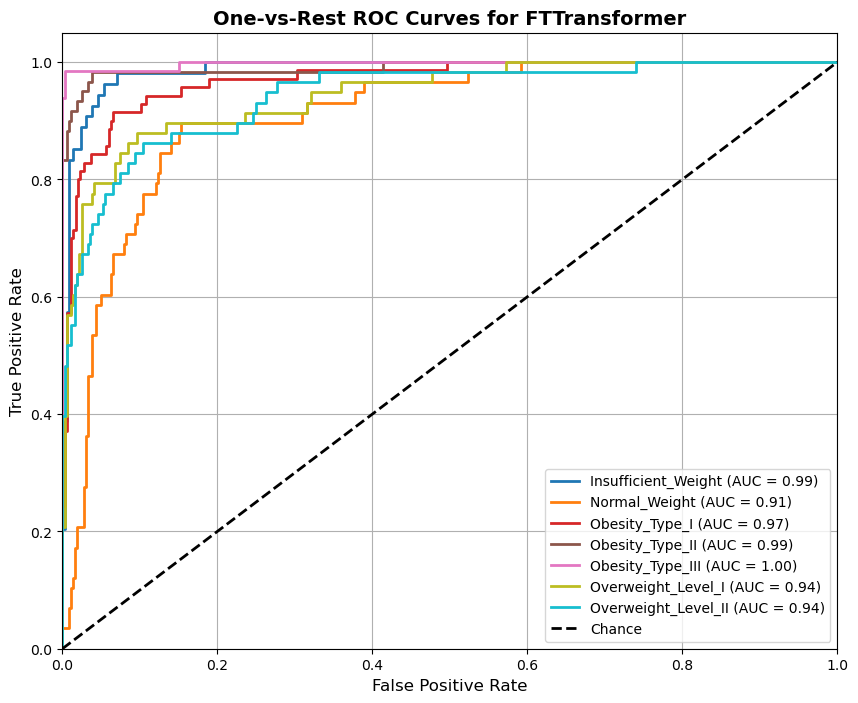

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assume test_true (true labels) and test_prob (predicted probability matrix) have been computed as in your evaluation code.
n_classes = 7  # There are 7 classes in your output.

# Binarize the test labels for multiclass ROC analysis.
y_test_bin = label_binarize(test_true, classes=list(range(n_classes)))

# Compute ROC curve and ROC area for each class.
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves.
class_names = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
    "Overweight_Level_I",
    "Overweight_Level_II"
]
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, color=colors(i),
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
    
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("One-vs-Rest ROC Curves for FTTransformer", fontsize=14, fontweight = "bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)

# Save the ROC curve plot as a PNG file with minimal margins.
plt.savefig("fttransformer_roc_curve.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Architecture summary

In [15]:
from torchviz import make_dot
import torch

# Define the cardinalities for each categorical feature.
cardinalities = [2, 2, 4, 2, 2, 4, 5]

# Create dummy categorical data: for each feature, sample an integer in [0, cardinality).
dummy_cat = torch.tensor([[torch.randint(0, c, (1,)).item() for c in cardinalities]]).to(device)

# Create dummy continuous data.
dummy_cont = torch.randn(1, num_continuous).to(device)

# Forward pass through the model.
dummy_output = model(dummy_cat, dummy_cont)

# Generate the computation graph and save it as a PNG file.
dot = make_dot(dummy_output, params=dict(model.named_parameters()))
dot.render("tabtransformer_model", format="png")

'tabtransformer_model.png'

In [16]:
from torchinfo import summary
summary(model, input_data=[dummy_cat, dummy_cont],
        depth=2,                   # show details up to two levels deep
        col_names=["input_size", "output_size", "num_params", "trainable"])                 # moderate verbosity

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
TabTransformer                                          [1, 7]                    [1, 7]                    28                        True
├─Embedding: 1-1                                        [1, 7]                    [1, 7, 28]                644                       True
├─Transformer: 1-2                                      [1, 7, 32]                [1, 7, 32]                --                        True
│    └─Reduce: 2-1                                      [1, 7, 32]                [4, 7, 32]                --                        --
│    └─ModuleList: 2-2                                  --                        --                        34,664                    True
│    └─Reduce: 2-3                                      [4, 7, 32]                [1, 7, 32]                --                        --
├─LayerNorm: 1-3          